In [ ]:
import sys
import numpy as np
import jax
import jax.numpy as jnp
from jax import jacfwd
from jax import jit
from jax import vmap
import emcee
import h5py
import corner
import matplotlib.pyplot as plt
import corner
import VBMicrolensing
VBM = VBMicrolensing.VBMicrolensing()
import tqdm
import math
import h5py
sys.path.append("/moao38_7/nunota/gapmoe/src/gapmoe/")
from gapmoe import gapmoe
import EarthMotion
import parametrics
# gapmoe_model = gapmoe(rhos_path="../test_data/hist_D.dat",mass_path="../test_data/hist_M.dat",mu_path="../test_data/hist_murel.dat")
# gapmoe_model.set_data()
JD0 = 0
from scipy.optimize import minimize

In [ ]:
def _wrap_pi(x):  # [-pi,pi]
    return (x + jnp.pi) % (2*jnp.pi) - jnp.pi

def _kepler_to_state_NE(a_AU, e, cos_i, Om_NE, om, nu, G, ML):
    i = jnp.arccos(cos_i)

    r_0 = a_AU*(1-e*e)/(1 + e * jnp.cos(nu))
    # perifocal frame
    r_pf = jnp.array([r_0 * jnp.cos(nu),
                      r_0 * jnp.sin(nu),
                      0.0])
    n = jnp.sqrt(G*ML/a_AU**3)
    v_pf = jnp.array([-n*a_AU*jnp.sin(nu)/jnp.sqrt(1-e*e),
                       n*a_AU*(e+jnp.cos(nu))/jnp.sqrt(1-e*e),
                       0.0])
    
    cO,sO = jnp.cos(Om_NE), jnp.sin(Om_NE)
    co,so = jnp.cos(om), jnp.sin(om)
    ci,si = cos_i, jnp.sqrt(1-cos_i**2)
    Rz_Om = jnp.array([[ cO,-sO,0.0],
                       [ sO, cO,0.0],
                       [0.0,0.0,1.0]])
    Rx_i  = jnp.array([[1.0,0.0,0.0],
                       [0.0, ci,-si],
                       [0.0, si, ci]])
    Rz_om = jnp.array([[ co,-so,0.0],
                       [ so, co,0.0],
                       [0.0,0.0,1.0]])
    R = Rz_Om @ Rx_i @ Rz_om
    r = R @ r_pf
    v = R @ v_pf
    return r, v

def inverse_lightcurve_params_from_physical(
    phys, thS, vEarth_NE,
    G=2.959122082855911e-4,   # AU^3 / (Msun * day^2)
    KAPPA=8.1429              # mas / Msun
):
    """
    phys = [t0, u0, q, ML, DL, DS, muN_hel, muE_hel, a_AU, e, cos_i, Om_NE, om, nu]
    return: theta = [t0, tE, u0, rho, q, s, alpha,
                     piEN, piEE, gamma1, gamma2, gamma3, r_s, a_s]
    """
    (t0, u0, q, ML, DL, DS, muN_hel, muE_hel,
     a_AU, e, cos_i, Om_NE, om, nu) = phys

    # 1) NEで r,v
    r_AU, v_AU_d = _kepler_to_state_NE(a_AU, e, cos_i, Om_NE, om, nu, G, ML)

    # 2) θE, πE, RE
    pi_S = 1.0/DS         # 1/kpc
    pi_L = 1.0/DL
    pi_rel = pi_L - pi_S  # 1/kpc
    thE = jnp.sqrt(KAPPA * ML * pi_rel)   # mas
    piE = pi_rel / thE                     # dimensionless
    RE  = DL * thE                         # AU  (1 mas × 1 kpc = 1 AU)

    # 3) μ_geo と tE
    muN_geo = muN_hel - thE * piE * vEarth_NE[0]
    muE_geo = muE_hel - thE * piE * vEarth_NE[1]
    mu_geo  = jnp.sqrt(muN_geo**2 + muE_geo**2)  # mas/yr
    tE = thE / (mu_geo / 365.25)                 # day

    # πE の向き(μ_geo に合わせる)
    ang_mu = jnp.arctan2(muE_geo, muN_geo)
    piEN = piE * jnp.cos(ang_mu)
    piEE = piE * jnp.sin(ang_mu)

    # 4) binary axix 座標の基底（rで定義）
    z_hat = jnp.array([0.0, 0.0, 1.0]) # LOS 
    p = r_AU - jnp.dot(r_AU, z_hat) * z_hat  #天球面へ射影したr_AUベクトル
    p_norm = jnp.linalg.norm(p)
    eps = 1e-300
    xB = p / (p_norm + eps)
    yB = jnp.cross(z_hat, xB)
    yB = yB / (jnp.linalg.norm(yB) + eps)       # 念のため正規化

    # 5) s, r_s, gammas
    s = p_norm / (RE + eps)
    r_s = (jnp.dot(r_AU, z_hat)) / ((RE + eps) * (s + eps))
    gamma1 = jnp.dot(v_AU_d, xB) / ((RE + eps) * (s + eps))
    gamma2 = jnp.dot(v_AU_d, yB) / ((RE + eps) * (s + eps))
    gamma3 = jnp.dot(v_AU_d, z_hat) / ((RE + eps) * (s + eps))

    # 6) a_s
    a_scaled = a_AU / (RE + eps)
    a_s = a_scaled / (s * jnp.sqrt(1 + r_s**2) + eps)

    # 7) alpha
    h = jnp.cross(
        jnp.array([p_norm, 0, r_AU[2]]),
        jnp.array([
            jnp.dot(v_AU_d, xB),
            jnp.dot(v_AU_d, yB),
            jnp.dot(v_AU_d, z_hat)
        ])
    ) # angular momentum in binary axis  coordinate
    
    z_orb = h / (jnp.linalg.norm(h) + eps)
    Om0 = jnp.arctan2(z_orb[0], -z_orb[1]) 
    alpha = Om0 + jnp.arctan2(piEE, piEN) - Om_NE
    alpha = _wrap_pi(alpha)

    rho = thS / thE

    theta = jnp.array([t0, tE, u0, rho, q, s, alpha,
                       piEN, piEE, gamma1, gamma2, gamma3, r_s, a_s])
    return theta

In [ ]:
from matplotlib import rcParams
rcParams["font.size"] = 15
rcParams["axes.linewidth"] = 3
rcParams['xtick.top'] = True
rcParams['ytick.right'] = True
rcParams['xtick.direction'] = 'in'
rcParams['ytick.direction'] = 'in'
rcParams['xtick.major.size'] = 10
rcParams['xtick.major.width'] = 1.5
rcParams['xtick.minor.size'] = 5
rcParams['xtick.minor.width'] = 1.5
rcParams['ytick.major.size'] = 10
rcParams['ytick.major.width'] = 1.5
rcParams['ytick.minor.size'] = 5
rcParams['ytick.minor.width'] = 1.5

In [ ]:
def mag2flux(mag):
    return 10**(-mag / 2.5)

def flux2mag(flux):
    return -2.5 * np.log10(flux)

def magerr2fluxerr(mag, mag_err):
    flux = mag2flux(mag)
    flux_err = flux * (np.log(10) / 2.5) * mag_err
    return flux_err

In [ ]:
def linear_fit(x,y,w):
    w_sum = np.sum(w)
    wxy_sum = np.sum(w*x*y)
    wx_sum = np.sum(w*x)
    wy_sum = np.sum(w*y)
    wxx_sum = np.sum(w*x*x)
    bunbo = w_sum*wxx_sum-wx_sum**2
    a = (w_sum*wxy_sum-wx_sum*wy_sum)/bunbo
    b = (wxx_sum*wy_sum-wx_sum*wxy_sum)/bunbo
    y_fit = a * x + b
    chi2 = np.sum(w * (y - y_fit) ** 2)
    return a,b,chi2

In [ ]:
cVIBoya = 0.50141358
dVIBoya = 0.41968496
EVI, AI = 1.483,  1.822
def calc_thS(_fs_I,_fs_v):
    I_S = flux2mag(_fs_I)
    V_S = flux2mag(_fs_v)
    VI_S = V_S - I_S
    
    I0_S = I_S - AI
    VI0_S = VI_S - EVI
    
    _theta_star  = 0.5*10**(cVIBoya + dVIBoya*VI0_S  - 0.2*I0_S)
    return _theta_star

In [ ]:
path_moa = "/moao38_7/nunota/HSC_FFP/colab_data/moa_magerror_clear.dat"
data_moa = np.genfromtxt(path_moa,names=["mag","med","ul","ll"],usecols=[0,1,2,3])

mag_vals_moa = data_moa['mag']
med_vals_moa = data_moa['med']
ul_vals_moa = data_moa['ul']
ll_vals_moa = data_moa['ll']

def get_mag_err_moa(mag):
    med_interp = np.interp(mag, mag_vals_moa, med_vals_moa)
    ul_interp = np.interp(mag, mag_vals_moa, ul_vals_moa)
    ll_interp = np.interp(mag, mag_vals_moa, ll_vals_moa)

    sigma = (ul_interp - ll_interp) / 4 
    random_value = np.random.normal(med_interp, sigma)

    return np.clip(random_value, ll_interp, ul_interp)

In [ ]:
list_path = "../../binfit/work/MB23162/data/v2/list_vbml"

#----------read list------------#
data_path_list, data_names = {},[]
with open(list_path,"r") as f:
    for line in f:
        line = line.strip().split()
        _tmp_name = line[1]+"_"+line[2]
        data_names.append(_tmp_name)
        data_path_list[_tmp_name] = line[0]

data_set = {}
for _name in data_names:
    _tmp_data = np.genfromtxt("../../binfit/work/MB23162/"+data_path_list[_name],usecols=(0,1,2),names=["time","flux","ferr"])
    _tmp_data = _tmp_data[np.where(_tmp_data["ferr"]>0)]
    _tmp_data = _tmp_data[np.where((_tmp_data["time"]>9700)&(_tmp_data["time"]<10500))]
    data_set[_name] = _tmp_data

In [ ]:
data_set.keys()

In [ ]:
Is = 16 + AI
Vs = 1 + 18 + EVI
fs_I = mag2flux(Is)
fs_V = mag2flux(Vs)
thS =jnp.float32(calc_thS(fs_I, fs_V))
print(thS)
print("\n")     

In [ ]:
Is,Vs

In [34]:
t0 = 10090
u0 = -0.02 
q = 0.01
ML = 0.7
DL = 1.5
DS = 8.1
muN_hel = 4
muE_hel = -4
a_AU = 2.3
e = 0.2
cos_i = 0.1
Om_NE = 0.1-np.pi
om = -1
nu = -2

tref = t0
coords = "17:57:38.03 -28:38:28.53"
VBM.t0_par = tref+JD0
VBM.parallaxsystem = 1
VBM.SetObjectCoordinates(coords)
RA_str,Dec_str = "17:57:38.03","-28:38:28.53"
RA_deg = EarthMotion.hms_string_to_degrees(RA_str)
Dec_deg = EarthMotion.dms_string_to_degrees(Dec_str)
vEarth = EarthMotion.calc_vEarth(tref+2450000,RA_deg,Dec_deg)

phys = jnp.array([t0, u0, q, ML, DL, DS, muN_hel, muE_hel,a_AU, e, cos_i, Om_NE, om, nu])

x =  inverse_lightcurve_params_from_physical(phys, thS, vEarth)
t0, tE, u0, rho ,q, s, alpha, piEN, piEE, gamma1, gamma2, gamma3,r_s,a_s = x 
pr = [math.log(s), math.log(q), u0, alpha, math.log(rho), math.log(tE), t0+JD0, piEN, piEE, gamma1,gamma2,gamma3,r_s,a_s]

print("\n")
print(f"t0_true = {t0:.6g}")       # days
print(f"q_true = {q:.6g}")     # dimensionless
print(f"u0_true = {u0:.6g}")  
print(f"alpha_true = {alpha:.6g}")  
print(f"tE_true = {tE:.6g}")       # days
print(f"rho_true = {rho:.6g}")     # dimensionless
print(f"s_true = {s:.6g}")         # projected separation
print(f"piEN_true = {piEN:.6g}")   # microlens parallax N
print(f"piEE_true = {piEE:.6g}")   # microlens parallax E
print(f"gamma1_true = {gamma1:.6g}")  # orbital motion
print(f"gamma2_true = {gamma2:.6g}")
print(f"gamma3_true = {gamma3:.6g}")
print(f"r_s_true = {r_s:.6g}")  # orbital motion
print(f"a_s_true = {a_s:.6g}")
print("\n")


print(t0, u0, q)
print(f"μ_rel_N   = {muN_hel:.6f}  # mas/yr")
print(f"μ_rel_E   = {muE_hel:.6f}  # mas/yr")
print(f"M_L       = {ML:.6f}       # M_sun")
print(f"D_L       = {DL:.6f}       # kpc")
print(f"D_S       = {DS:.6f}       # kpc")
print(f"R_orbit   = {a_AU:.6f}  # AU")
print(f"e    = {e:.6f}")
print(f"cos(i)    = {cos_i:.6f}")
print(f"0mega    = {Om_NE:.6f}")
print(f"omega    = {om:.6f}")
print(f"nu    = {nu:.6f}")



t0_true = 10090
q_true = 0.01
u0_true = -0.02
alpha_true = -0.347735
tE_true = 151.64
rho_true = 0.00177562
s_true = 0.903443
piEN_true = 0.30033
piEE_true = -0.0714238
gamma1_true = -0.00125154
gamma2_true = 0.000376098
gamma3_true = -0.00356426
r_s_true = -0.141818
a_s_true = 0.954969


10090.0 -0.02 0.01
μ_rel_N   = 4.000000  # mas/yr
μ_rel_E   = -4.000000  # mas/yr
M_L       = 0.700000       # M_sun
D_L       = 1.500000       # kpc
D_S       = 8.100000       # kpc
R_orbit   = 2.300000  # AU
e    = 0.200000
cos(i)    = 0.100000
0mega    = -3.041593
omega    = -1.000000
nu    = -2.000000


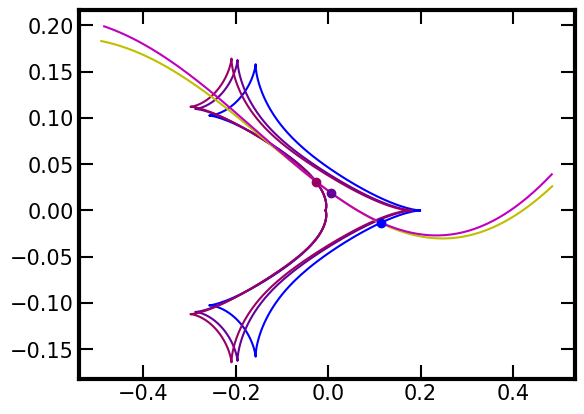

In [35]:
t = np.linspace(t0-0.5*tE+JD0, t0+JD0+0.5*tE, 300)
_, y1, y2,sorb = VBM.BinaryLightCurveKepler(pr,t)   
_, y1para, y2para = VBM.BinaryLightCurveParallax(pr,t)   

caustictimes = [115,150,160]
colors = [(0,0,1,1),(0.4,0,0.6,1),(0.6,0,0.4,1)]
for i in range(0,3):
    caustics = VBM.Caustics(sorb[caustictimes[i]],q)
    for cau in caustics:
        plt.plot(cau[0],cau[1],color = colors[i])
plt.plot(y1,y2,"y")
plt.plot(y1para,y2para,"m")
for i in range(0,3):
    plt.plot([y1[caustictimes[i]]],[y2[caustictimes[i]]],color=colors[i],marker="o")


In [40]:
np.random.seed(45)

simu_data = {}
for name in data_set.keys():
#     if "KMT" in name:
#         continue
    if "42" in name or "43" in name: 
        continue
    time = data_set[name]["time"]
    amp = np.array(VBM.BinaryLightCurveKepler(pr, time + JD0)[0])
    
    if "I" in name or "Red" in name:
        model_flux = amp * fs_I + mag2flux(20)
    else:
        model_flux = amp * fs_V + mag2flux(22)

    lc_model = np.empty(len(time), dtype=[
        ("time", float), 
        ("flux", float),      
        ("mag", float),     
        ("merr", float),    
        ("ferr", float),    
        ("mag_obs", float), 
        ("flux_obs", float),
    ])
    
    lc_model["time"] = time
    lc_model["flux"] = model_flux
    lc_model["mag"] = flux2mag(model_flux)

    if "I" in name or "Red" in name:
        lc_model["merr"] = get_mag_err_moa(lc_model["mag"]) * 100 / np.sqrt(10)
    else:
        lc_model["merr"] = get_mag_err_moa(lc_model["mag"]) * 200/ np.sqrt(10)

    lc_model["ferr"] = np.abs(
        magerr2fluxerr(lc_model["mag"], lc_model["merr"])
    )

    lc_model["flux_obs"] = lc_model["flux"] + np.random.normal(0, lc_model["ferr"])
    lc_model["mag_obs"] = flux2mag(lc_model["flux_obs"])

    simu_data[name] = lc_model

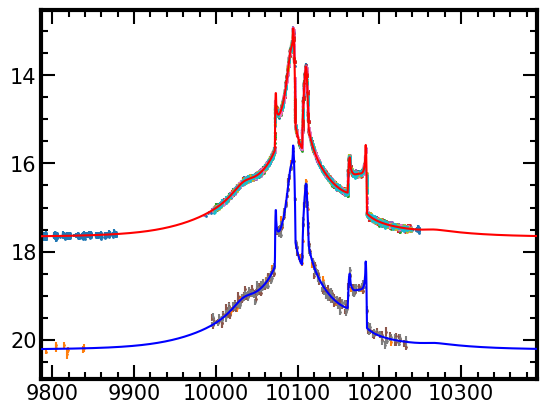

In [41]:
t_plot = np.linspace(t0-10*tE+JD0, t0+JD0+10*tE,10000)
amp_plot = np.array(VBM.BinaryLightCurveKepler(pr, t_plot)[0])
mag_plot_I = flux2mag(amp_plot * fs_I + mag2flux(20))
mag_plot_V = flux2mag(amp_plot * fs_V + mag2flux(22))
plt.plot(t_plot,mag_plot_I,c="red",zorder=10)
plt.plot(t_plot,mag_plot_V,c="blue",zorder=10)

for name in simu_data.keys():
    plt.errorbar(simu_data[name]["time"]+JD0, simu_data[name]["mag_obs"], simu_data[name]["merr"],fmt="o",markersize=1)
    
plt.xlim(t0-2*tE+JD0, t0+JD0+2*tE,)
plt.minorticks_on()
plt.gca().invert_yaxis()

plt.show()

In [38]:
# np.savez("../simu_data/simu_data_04_kepler.npz", **simu_data)

In [39]:
chi2_total = 0.0
chi2_dict = {}

for name, lc in simu_data.items():
    # χ²を各データセットごとに計算
    chi2 = np.sum(((lc["flux_obs"] - lc["flux"]) / lc["ferr"]) ** 2)
    chi2_dict[name] = chi2
    chi2_total += chi2

print("個別chi²:")
for k, v in chi2_dict.items():
    print(f"{k:15s}: {v:.3f}")

print(f"\n総合chi² = {chi2_total:.3f}")


個別chi²:
MOA_Red        : 4481.570
MOA_V          : 73.855
KMT-A02_I      : 2769.354
KMT-A03_I      : 2709.763
KMT-C02_I      : 2175.447
KMT-C02_V      : 179.912
KMT-C03_I      : 2311.565
KMT-C03_V      : 186.994
KMT-S02_I      : 2186.810
KMT-S03_I      : 1875.252

総合chi² = 18950.522
